In [1]:
import os
import torch
import numpy as np
import umap
import random
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import Pk_library as PKL

from module_newnew import FlowMatchingModel

import scienceplots
plt.style.use('science')

from contextlib import contextmanager
import sys, os

@contextmanager
def suppress_stdout():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        sys.stdout = devnull
        try:  
            yield
        finally:
            sys.stdout = old_stdout

def get_pk(mat):
    BoxSize = 25.0    
    MAS     = 'None'  
    threads = 1   
    delta = (mat-mat.mean()) / mat.std()
    pk = PKL.Pk_plane(delta,BoxSize,MAS,threads,verbose=False)
    # print(np.asarray(pk.k).max())
    return pk.k, pk.Pk

def get_xcorr(delta1, delta2):
    BoxSize = 25
    MAS1    = 'None'
    MAS2    = 'None'
    threads = 1
    with suppress_stdout():
        XPk2D = PKL.XPk_plane(delta1, delta2, BoxSize, MAS1, MAS2, threads)
    return XPk2D.k, XPk2D.XPk / np.sqrt(XPk2D.Pk[:,0] * XPk2D.Pk[:,1])

def load_model(checkpoint_path, device=None):
    """Load trained flow matching model from checkpoint"""
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = FlowMatchingModel.load_from_checkpoint(checkpoint_path, map_location=device)
    model.to(device)
    model.eval()
    return model, device

In [2]:
class ResNetEmbeddingExtractor:
    """
    Alternative extractor that directly extracts ResNet embeddings without 
    needing to run the full UNet forward pass
    """
    def __init__(self, checkpoint_path):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = FlowMatchingModel.load_from_checkpoint(checkpoint_path)
        self.model.to(self.device)
        self.model.eval()
        
    def extract_embeddings(self, total_mass, star_maps, gas_maps, T_maps, P_maps, astro_params, batch_size=25):
        """
        Directly extract ResNet embeddings without running the full model
        """
        all_embeddings = []
        n_samples = len(total_mass)
        
        for i in range(0, n_samples, batch_size):
            end_idx = min(i + batch_size, n_samples)
            
            # Prepare target maps tensor
            target_maps = torch.stack([
                torch.FloatTensor(star_maps[i:end_idx]),
                torch.FloatTensor(gas_maps[i:end_idx]),
                torch.FloatTensor(T_maps[i:end_idx]),
                torch.FloatTensor(P_maps[i:end_idx])
            ], dim=1).to(self.device)
            
            with torch.no_grad():
                # Directly compute ResNet embeddings
                embeddings = self.model.resnet_branch(target_maps)
                all_embeddings.append(embeddings.detach().cpu().numpy())
            
            # Clear memory
            del target_maps
            torch.cuda.empty_cache()
        
        return np.vstack(all_embeddings) if all_embeddings else np.array([])
    
    def extract_custom_embeddings(self, custom_input, batch_size=25):
        """
        Extract embeddings from custom input tensors
        """
        all_embeddings = []
        n_samples = custom_input.shape[0]
        
        for i in range(0, n_samples, batch_size):
            end_idx = min(i + batch_size, n_samples)
            
            input_batch = torch.FloatTensor(custom_input[i:end_idx]).to(self.device)
            
            with torch.no_grad():
                embeddings = self.model.resnet_branch(input_batch)
                all_embeddings.append(embeddings.detach().cpu().numpy())
            
            del input_batch
            torch.cuda.empty_cache()
        
        return np.vstack(all_embeddings) if all_embeddings else np.array([])

In [46]:
class AnalysisPipeline:
    """
    Unified pipeline that combines data loading, embedding extraction, and sampling analysis
    """
    def __init__(self, checkpoint_path, data_dir="/n/netscratch/iaifi_lab/Lab/msliu/CMD/data"):
        self.checkpoint_path = checkpoint_path
        self.data_dir = data_dir
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model, self.device = load_model(self.checkpoint_path)

        # Initialize extractor
        self.extractor = ResNetEmbeddingExtractor(checkpoint_path)
        
        # Storage for loaded datasets
        self.loaded_datasets = {}
        self.all_features_resnet = []
        self.all_labels_resnet = []
        self.all_cosmo_params = []
        self.all_astro_params = []
        
    def load_model_data(self, model_name, dataset, n_samples=500):
        """Load and normalize data following training pattern exactly"""
        
        # Load full datasets
        total_mass = np.load(f'{self.data_dir}/{model_name}/Maps_Mcdm_{model_name}_{dataset}_z=0.00.npy')
        star_maps = np.load(f'{self.data_dir}/{model_name}/Maps_Mstar_{model_name}_{dataset}_z=0.00.npy')
        gas_maps = np.load(f'{self.data_dir}/{model_name}/Maps_Mgas_{model_name}_{dataset}_z=0.00.npy')
        T_maps = np.load(f'{self.data_dir}/{model_name}/Maps_T_{model_name}_{dataset}_z=0.00.npy')
        P_maps = np.load(f'{self.data_dir}/{model_name}/Maps_P_{model_name}_{dataset}_z=0.00.npy')
        params = np.loadtxt(f'{self.data_dir}/{model_name}/params_{dataset}_{model_name}.txt')
        
        # Apply log1p transformation (training pattern)
        total_mass_log = np.log1p(total_mass)
        star_maps_log = np.log1p(star_maps)
        gas_maps_log = np.log1p(gas_maps)
        T_maps_log = np.log1p(T_maps)
        P_maps_log = np.log1p(P_maps)
        
        # Compute normalization from full dataset
        tot_mean, tot_std = total_mass_log.mean(), total_mass_log.std()
        star_mean, star_std = star_maps_log.mean(), star_maps_log.std()
        gas_mean, gas_std = gas_maps_log.mean(), gas_maps_log.std()
        T_mean, T_std = T_maps_log.mean(), T_maps_log.std()
        P_mean, P_std = P_maps_log.mean(), P_maps_log.std()
        
        # Sample and normalize
        if len(total_mass_log) > n_samples:
            indices = np.random.choice(len(total_mass_log), n_samples, replace=False)
            total_mass = (total_mass_log[indices] - tot_mean) / tot_std
            star_maps = (star_maps_log[indices] - star_mean) / star_std
            gas_maps = (gas_maps_log[indices] - gas_mean) / gas_std
            T_maps = (T_maps_log[indices] - T_mean) / T_std
            P_maps = (P_maps_log[indices] - P_mean) / P_std
            cosmo_params = [np.append(params[i//15,:2],[0.049,0.6711,0.9624]) for i in indices]
            astro_params = params[indices//15, 2:]  
        else:
            total_mass = (total_mass_log - tot_mean) / tot_std
            star_maps = (star_maps_log - star_mean) / star_std
            gas_maps = (gas_maps_log - gas_mean) / gas_std
            T_maps = (T_maps_log - T_mean) / T_std
            P_maps = (P_maps_log - P_mean) / P_std
            cosmo_params = np.repeat([np.append(p[:2],[0.049,0.6711,0.9624]) for p in params],15,axis=0)
            astro_params = np.repeat(params[:,2:],15,axis=0)
        
        return total_mass, star_maps, gas_maps, T_maps, P_maps, cosmo_params, astro_params
    
    def extract_embedding(self, simulation_models, dataset='LH', n_samples=5000, extract_features=True):
        """
        Process all simulation models: load data and optionally extract features
        
        Args:
            simulation_models: List of model names
            n_samples: Number of samples to load per model
            extract_features: Whether to extract ResNet features
        """
        print("Processing simulation models...")
        
        for model_name in simulation_models:
            print(f"Processing {model_name}...")
            
            # Load data
            total_mass, star_maps, gas_maps, T_maps, P_maps, cosmo_params, astro_params = self.load_model_data(
                model_name, dataset, n_samples=n_samples
            )
            
            # Store loaded data
            self.loaded_datasets[model_name] = (total_mass, star_maps, gas_maps, T_maps, P_maps, cosmo_params, astro_params)
            
            # Extract features if requested
            if extract_features:
                features = self.extractor.extract_embeddings(total_mass, star_maps, gas_maps, T_maps, P_maps, cosmo_params)
                
                if len(features) > 0:
                    self.all_features_resnet.append(features)
                    self.all_labels_resnet.extend([model_name] * len(features))
                    self.all_cosmo_params.append(cosmo_params)
                    self.all_astro_params.append(astro_params)
        
        print(f"Completed processing {len(simulation_models)} models")
        
        if extract_features and self.all_features_resnet:
            X_resnet_combined = np.vstack(self.all_features_resnet)
            print(f"Total extracted features: {X_resnet_combined.shape}")
            return X_resnet_combined
        
        return None
    
    def sampling(self, ids, num_steps=50):
        """
        Run the five-sample analysis using loaded datasets
        
        Args:
            ids: List of indices for each model
            num_steps: Number of sampling steps
        """
        if not self.loaded_datasets:
            raise ValueError("No datasets loaded. Run extract_embedding() first.")
        
        print("Running five-sample analysis...")
        return self.five_samples(ids, num_steps)

    def inference(self, cdm_mass, params, resnet_embed=None, resnet_input=None, num_steps=100):

        if resnet_input is not None:
            resnet_input = torch.tensor(resnet_input, dtype=torch.float32).unsqueeze(0).to(self.device)
        if resnet_embed is not None:
            resnet_embed = torch.tensor(resnet_embed, dtype=torch.float32).unsqueeze(0).to(self.device)
        cdm_mass = torch.tensor(cdm_mass, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(self.device)
        params = torch.tensor(params, dtype=torch.float32).unsqueeze(0).to(self.device)
        
        with torch.no_grad():
            pred = self.model.sample(
                cdm_mass=cdm_mass,  
                astro_params=params,  
                resnet_input=resnet_input,  
                resnet_embed=resnet_embed,
                num_steps=num_steps,
                method='euler'
            ).cpu().numpy()[0]
        return pred
    
    def five_samples(self, ids, num_steps=50):
        """
        Analysis function that uses already loaded data
        """        
        model_names = list(self.loaded_datasets.keys())
        
        # Data stats (since data is already normalized, use default values)
        data_stats = {'tot_mean': 0.0, 'tot_std': 1.0}

        # Initialize result containers
        preds_all, stars_true_all, gas_true_all, T_true_all, P_true_all, tot_mass_all, params_list_all = [], [], [], [], [], [], []
        star_pk_results, gas_pk_results, T_pk_results, P_pk_results = [], [], [], []
        star_corr_results, gas_corr_results, T_corr_results, P_corr_results = [], [], [], []
        dataset_labels = []

        # Process all datasets
        for i, model_name in enumerate(model_names):
            if i >= len(ids):
                print(f"Warning: No index provided for {model_name}, skipping...")
                continue
                
            idx = ids[i]
            total_mass, star_maps, gas_maps, T_maps, P_maps, cosmo_params, astro_params = self.loaded_datasets[model_name]
            
            # Check if index is valid
            if idx >= len(total_mass):
                print(f"Warning: Index {idx} out of range for {model_name} (max: {len(total_mass)-1}), skipping...")
                continue
            
            # Get the sample data (already normalized by load_model_data)
            sample_tot_norm = total_mass[idx]
            star_map_norm = star_maps[idx]
            gas_map_norm = gas_maps[idx]
            T_map_norm = T_maps[idx]
            P_map_norm = P_maps[idx]
            cosmo_params_sample = cosmo_params[idx]

            # Create noisy versions of the total mass map
            noisy_tot_list = [
                sample_tot_norm + np.random.normal(loc=0, scale=0.2, size=(256, 256))
                for _ in range(5)
            ]

            # Stack all four channels: star, gas, temperature, P
            truth_maps = np.stack([star_map_norm, gas_map_norm, T_map_norm, P_map_norm], axis=0)
            
            # Process each noisy version
            for noisy_tot in noisy_tot_list:
                
                pred = self.inference(
                    cdm_mass=noisy_tot,
                    params=cosmo_params_sample,
                    resnet_input=truth_maps,
                    num_steps=num_steps
                )

                # Store results
                preds_all.append(pred)
                stars_true_all.append(star_map_norm)
                gas_true_all.append(gas_map_norm)
                T_true_all.append(T_map_norm)
                P_true_all.append(P_map_norm)
                tot_mass_all.append(noisy_tot)
                params_list_all.append(cosmo_params_sample)
                dataset_labels.append(model_name)

                # Power spectrum analysis for all four channels
                # Stars
                k_star_pred, pk_star_pred = get_pk(pred[0])
                k_star_true, pk_star_true = get_pk(star_map_norm)
                star_pk_results.append({
                    'k': k_star_pred,
                    'pk_pred': pk_star_pred,
                    'pk_true': pk_star_true,
                    'error': np.abs(pk_star_pred - pk_star_true) / (pk_star_true + 1e-10)
                })

                # Gas
                k_gas_pred, pk_gas_pred = get_pk(pred[1])
                k_gas_true, pk_gas_true = get_pk(gas_map_norm)
                gas_pk_results.append({
                    'k': k_gas_pred,
                    'pk_pred': pk_gas_pred,
                    'pk_true': pk_gas_true,
                    'error': np.abs(pk_gas_pred - pk_gas_true) / (pk_gas_true + 1e-10)
                })

                # Temperature
                k_T_pred, pk_T_pred = get_pk(pred[2])
                k_T_true, pk_T_true = get_pk(T_map_norm)
                T_pk_results.append({
                    'k': k_T_pred,
                    'pk_pred': pk_T_pred,
                    'pk_true': pk_T_true,
                    'error': np.abs(pk_T_pred - pk_T_true) / (pk_T_true + 1e-10)
                })

                # Pressure
                k_P_pred, pk_P_pred = get_pk(pred[3])
                k_P_true, pk_P_true = get_pk(P_map_norm)
                P_pk_results.append({
                    'k': k_P_pred,
                    'pk_pred': pk_P_pred,
                    'pk_true': pk_P_true,
                    'error': np.abs(pk_P_pred - pk_P_true) / (pk_P_true + 1e-10)
                })

                # Correlation analysis
                r_star, xi_star = get_xcorr(pred[0], star_map_norm)
                r_gas, xi_gas = get_xcorr(pred[1], gas_map_norm)
                r_T, xi_T = get_xcorr(pred[2], T_map_norm)
                r_P, xi_P = get_xcorr(pred[3], P_map_norm)
                
                star_corr_results.append({'r': r_star, 'xi': xi_star})
                gas_corr_results.append({'r': r_gas, 'xi': xi_gas})
                T_corr_results.append({'r': r_T, 'xi': xi_T})
                P_corr_results.append({'r': r_P, 'xi': xi_P})

        # Channel configuration for plotting
        channels = [
            (stars_true_all, preds_all, 0, 'plasma', '$M_*$'),
            (gas_true_all, preds_all, 1, 'Blues', '$M_{gas}$'),
            (T_true_all, preds_all, 2, 'Reds', 'T'),
            (P_true_all, preds_all, 3, 'Purples', '$P$')
        ]

        # Return everything in the same format as original
        return {
            'channels': channels,
            'preds_all': preds_all,
            'stars_true_all': stars_true_all,
            'gas_true_all': gas_true_all,
            'T_true_all': T_true_all,
            'P_true_all': P_true_all,
            'tot_mass_all': tot_mass_all,
            'params_list_all': params_list_all,
            'dataset_labels': dataset_labels,
            'power_spectra': {
                'star': star_pk_results,
                'gas': gas_pk_results,
                'T': T_pk_results,
                'P': P_pk_results
            },
            'correlations': {
                'star': star_corr_results,
                'gas': gas_corr_results,
                'T': T_corr_results,
                'P': P_corr_results
            },
            'data_stats': data_stats,
            'model': self.model,
            'device': self.device
        }
    
    def get_combined_features(self):
        """Get the combined feature matrix"""
        if self.all_features_resnet:
            return np.vstack(self.all_features_resnet)
        return None
    
    def get_labels(self):
        """Get the model labels"""
        return self.all_labels_resnet
    
    def get_parameters(self):
        """Get cosmological and astrophysical parameters"""
        return self.all_cosmo_params, self.all_astro_params


In [6]:
checkpoint_path = 'lightning_logs/newnew/checkpoints/best-model-epoch=143-val_loss=0.026560.ckpt'
simulation_models = ['SIMBA']
ids = [0]  # One for each model

pipeline = AnalysisPipeline(checkpoint_path)

# Load data and extract features
pipeline.extract_embedding(simulation_models, n_samples=5000,extract_features=False)

Processing simulation models...
Processing SIMBA...
Completed processing 1 models


In [47]:
checkpoint_path = 'lightning_logs/newnew/checkpoints/best-model-epoch=143-val_loss=0.026560.ckpt'
simulation_models = ['IllustrisTNG', 'EAGLE', 'SIMBA', 'Astrid', 'Magneticum']
ids = [0, 1, 2, 3, 4]  # One for each model

pipeline = AnalysisPipeline(checkpoint_path)

# Load data and extract features
X_resnet_indv = pipeline.extract_embedding(simulation_models, dataset='CV', n_samples=5000)

Processing simulation models...
Processing IllustrisTNG...
Processing EAGLE...
Processing SIMBA...
Processing Astrid...
Processing Magneticum...
Completed processing 5 models
Total extracted features: (1965, 8)


In [8]:
zbar=pipeline.get_combined_features()
print(zbar[astrid_idx],zbar[eagle_idx])


[-2.0311353 -1.4009844 -1.0538255  1.9516724  1.0149672  1.6882428
 -1.3680929 -1.0710725] [-2.005032   -1.3901358  -0.95909154  1.9537501   0.9552489   1.7834198
 -1.4026352  -0.91859984]


In [32]:
def interpolate_and_infer(pipeline, embedding_idx1, embedding_idx2, 
                         cdm_mass, cosmo_params, num_steps=100, 
                         alpha_values=None):
    
    if alpha_values is None:
        alpha_values = [0, 0.25, 0.5, 0.75, 1.0]
    
    # Get the combined features matrix
    X_resnet_combined = pipeline.get_combined_features()
    
    if X_resnet_combined is None:
        raise ValueError("No ResNet features found. Make sure extract_embedding() was run with extract_features=True")
    
    # Get the two embeddings to interpolate between
    embedding1 = X_resnet_combined[embedding_idx1]
    embedding2 = X_resnet_combined[embedding_idx2]
    
    print(f"Interpolating between embedding {embedding_idx1} and {embedding_idx2}")
    print(f"Embedding shapes: {embedding1.shape}, {embedding2.shape}")
    
    predictions = []
    
    for alpha in alpha_values:
        print(f"Running inference with alpha = {alpha}")
        
        # Linear interpolation: (1-alpha) * emb1 + alpha * emb2
        interpolated_embedding = (1 - alpha) * embedding1 + alpha * embedding2
        
        # Run inference with interpolated embedding
        pred = pipeline.inference(
            cdm_mass=cdm_mass,
            params=cosmo_params,
            resnet_embed=interpolated_embedding,
            num_steps=num_steps
        )
        
        predictions.append({
            'alpha': alpha,
            'prediction': pred,
            'interpolated_embedding': interpolated_embedding
        })
    
    return predictions

def get_embedding_info(pipeline):

    X_resnet = pipeline.get_combined_features()
    labels = pipeline.get_labels()
    cosmo_params, astro_params = pipeline.get_parameters()
    
    if X_resnet is None:
        return None
    
    # Flatten parameter arrays if needed
    cosmo_flat = np.vstack(cosmo_params) if cosmo_params else None
    astro_flat = np.vstack(astro_params) if astro_params else None
    
    info = {
        'total_embeddings': len(X_resnet),
        'embedding_shape': X_resnet[0].shape,
        'labels': labels,
        'cosmo_params': cosmo_flat,
        'astro_params': astro_flat
    }
    
    # Group by model
    model_indices = {}
    for i, label in enumerate(labels):
        if label not in model_indices:
            model_indices[label] = []
        model_indices[label].append(i)
    
    info['model_indices'] = model_indices
    
    return info

# Example usage:

# 1. Get information about available embeddings
embedding_info = get_embedding_info(pipeline)
print("Available embeddings:")
print(f"Total: {embedding_info['total_embeddings']}")
print(f"Shape: {embedding_info['embedding_shape']}")
print("\nEmbeddings per model:")
for model, indices in embedding_info['model_indices'].items():
    print(f"{model}: {len(indices)} embeddings (indices {indices[0]} to {indices[-1]})")

# 2. Select two embeddings to interpolate between
# For example, first embedding from IllustrisTNG and first from EAGLE
astrid_idx = embedding_info['model_indices']['Astrid'][1703]
eagle_idx = embedding_info['model_indices']['EAGLE'][0]

print(f"\nSelected embeddings:")
print(f"Astrid embedding: index {astrid_idx}")
print(f"EAGLE embedding: index {eagle_idx}")

# 3. Get a CDM mass map and cosmological parameters
# You can use one from your loaded datasets
model_name = 'Astrid'  # or any model you want
sample_idx = astrid_idx  # which sample from that model

total_mass, star_maps, gas_maps, T_maps, P_maps, cosmo_params, astro_params = pipeline.loaded_datasets[model_name]

# cdm_sample = total_mass[sample_idx]
# cosmo_sample = cosmo_params[sample_idx]

cdm_sample = total_mass[1703]
cosmo_sample = cosmo_params[1703]

# 4. Run interpolation and inference
interpolation_results = interpolate_and_infer(
    pipeline=pipeline,
    embedding_idx1=astrid_idx,
    embedding_idx2=eagle_idx,
    cdm_mass=cdm_sample,
    cosmo_params=cosmo_sample,
    num_steps=200,
    alpha_values=[0, 0.25, 0.5, 0.75, 1.0]
)

# 5. Examine results
print(f"\nGenerated {len(interpolation_results)} predictions")
for i, result in enumerate(interpolation_results):
    pred = result['prediction']
    alpha = result['alpha']
    print(f"Alpha {alpha}: prediction shape {pred.shape}")
    
    # You can now analyze each prediction
    # pred[0] = stellar mass map
    # pred[1] = gas mass map  
    # pred[2] = temperature map
    # pred[3] = pressure map

Available embeddings:
Total: 20720
Shape: (8,)

Embeddings per model:
IllustrisTNG: 5000 embeddings (indices 0 to 4999)
EAGLE: 5000 embeddings (indices 5000 to 9999)
SIMBA: 5000 embeddings (indices 10000 to 14999)
Astrid: 5000 embeddings (indices 15000 to 19999)
Magneticum: 720 embeddings (indices 20000 to 20719)

Selected embeddings:
Astrid embedding: index 16703
EAGLE embedding: index 5000
Interpolating between embedding 16703 and 5000
Embedding shapes: (8,), (8,)
Running inference with alpha = 0
Running inference with alpha = 0.25
Running inference with alpha = 0.5
Running inference with alpha = 0.75
Running inference with alpha = 1.0

Generated 5 predictions
Alpha 0: prediction shape (4, 256, 256)
Alpha 0.25: prediction shape (4, 256, 256)
Alpha 0.5: prediction shape (4, 256, 256)
Alpha 0.75: prediction shape (4, 256, 256)
Alpha 1.0: prediction shape (4, 256, 256)


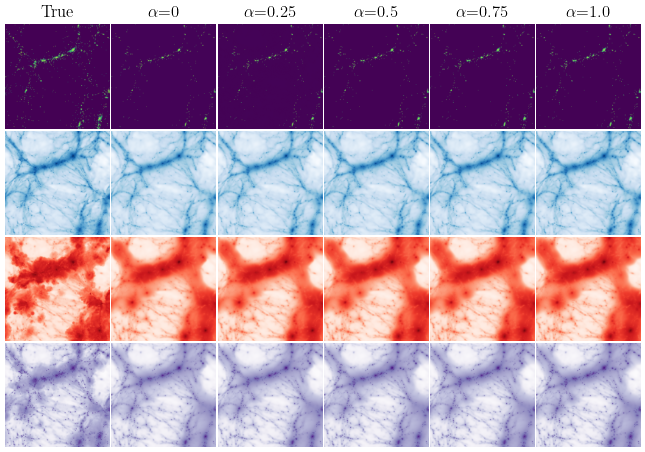

In [45]:
plt.figure(figsize=(8.2,5.5))
plt.subplots_adjust(wspace=0.02, hspace=0.01)
cls = ['viridis','Blues','Reds','Purples']
plt.subplot(4,6,1)
plt.imshow(star_maps[1703],cmap='viridis')
plt.title(f'True')
plt.axis('off')
plt.subplot(4,6,1+6)
plt.imshow(gas_maps[1703],cmap='Blues')
plt.axis('off')
plt.subplot(4,6,1+6*2)
plt.imshow(T_maps[1703],cmap='Reds')
plt.axis('off')
plt.subplot(4,6,1+6*3)
plt.imshow(P_maps[1703],cmap='Purples')
plt.axis('off')
for i,res in enumerate(interpolation_results):
    for j,(channel,cl) in enumerate(zip(res['prediction'],cls)):
        plt.subplot(4,6,i+j*6+2)
        if j==0:
            plt.title(f'$\\alpha$={res['alpha']}')
            plt.axis('off')
        else:
            plt.axis('off')
        plt.imshow(channel,cmap=cl)
# plt.tight_layout()
plt.show()


Processed with 1 steps
Processed with 2 steps
Processed with 4 steps
Processed with 8 steps
Processed with 16 steps
Processed with 32 steps
Processed with 64 steps


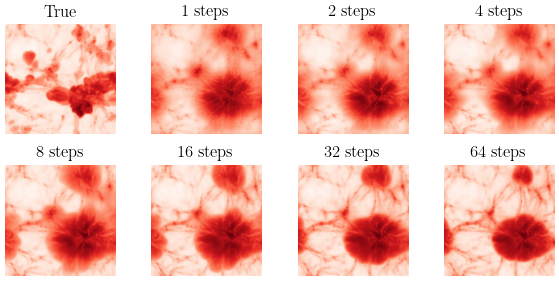

In [42]:
from contextlib import contextmanager
import sys, os

@contextmanager
def suppress_stdout():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        sys.stdout = devnull
        try:  
            yield
        finally:
            sys.stdout = old_stdout

all_T_corr = []
all_P_corr = []
steps = []

plt.figure(figsize=(6,3))
for n in range(7):
    step = 2**n
    with suppress_stdout():
        res = pipeline.sampling(ids=[42], num_steps=step)
    all_T_corr.append(res['correlations']['T'][0])
    all_P_corr.append(res['correlations']['P'][0])
    if n==0:
        plt.subplot(2,4,1)
        plt.imshow(res['T_true_all'][0],cmap='Reds')
        plt.axis('off')
        plt.title(f'True')
    plt.subplot(2,4,n+2)
    plt.imshow(res['preds_all'][0][2],cmap='Reds')
    plt.axis('off')
    plt.title(f'{step} steps')
    steps.append(step)
    print(f'Processed with {step} steps')
plt.tight_layout()
plt.show()

In [8]:
def integrator(X, Y, x_max=None):
    mask = X <= x_max if x_max else slice(None)
    X, Y = X[mask], Y[mask]
    return np.sum((X[1:]-X[:-1])*Y[:-1])/np.sum((X[1:]-X[:-1]))

xcors_T=[]
xcors_P=[]
for t,p in zip(all_T_corr,all_P_corr):
    xcors_T.append(integrator(t['r'],t['xi'],x_max=32))
    xcors_P.append(integrator(p['r'],p['xi'],x_max=32))

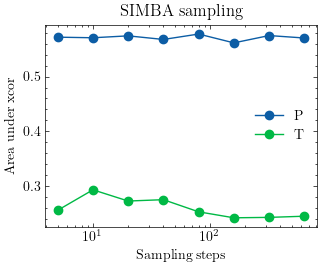

In [9]:
plt.plot(steps,xcors_P,label='P',marker='o')
plt.plot(steps,xcors_T,label='T',marker='o')
plt.xscale('log')
plt.legend()
plt.xlabel('Sampling steps')
plt.ylabel('Area under xcor')
plt.title('SIMBA sampling')
plt.savefig('area_steps.png')
plt.show()

In [6]:
# Run analysis
results = pipeline.sampling(ids=[0, 1, 2, 4, 5], num_steps=10000)

# Access individual components
labels = pipeline.get_labels()
cosmo_params, astro_params = pipeline.get_parameters()

Running five-sample analysis...


In [5]:
# Visualize
all_labels_resnet = pipeline.get_labels()
reducer = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, verbose=False)
embedding_tsne_indv = reducer.fit_transform(X_resnet_indv)

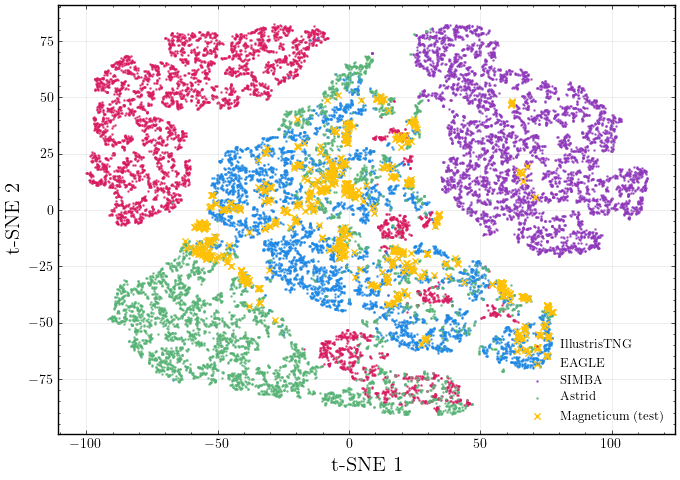

Visualization saved. Total samples: 20720


In [6]:
plt.figure(figsize=(7, 5))
colors = ['#D81B60','#1E88E5','#8F38BB','#57B375','#FFC107']
# colors = ['#E74C3C', '#3498DB', '#27AE60', '#9B59B6', '#F39C12']
for i, model_name in enumerate(simulation_models):
    mask = [label == model_name for label in all_labels_resnet]
    plt.scatter(embedding_tsne_indv[mask, 0], embedding_tsne_indv[mask, 1], marker='x' if model_name=='Magneticum' else '.',
               c=colors[i], label='Magneticum (test)' if model_name=='Magneticum' else model_name, alpha=1 if model_name=='Magneticum' else 0.7, s=20 if model_name=='Magneticum' else 3)
# plt.title('5-Channel ResNet Bottleneck by Simulation Model (PCA+t-SNE)')
plt.xlabel('t-SNE 1',fontsize=15)
plt.ylabel('t-SNE 2',fontsize=15)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
# Make the frame thicker
for spine in plt.gca().spines.values():
    spine.set_linewidth(1)
plt.tight_layout()
plt.savefig("tsne_resnet_newnew.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Visualization saved. Total samples: {len(embedding_tsne_indv)}")

In [7]:
import umap

all_labels_resnet = pipeline.get_labels()
reducer = umap.UMAP(n_neighbors=15,min_dist=0.1,n_components=2,random_state=42,verbose=False)
embedding_umap_indv = reducer.fit_transform(X_resnet_indv)

/n/home02/msliu/.conda/envs/env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


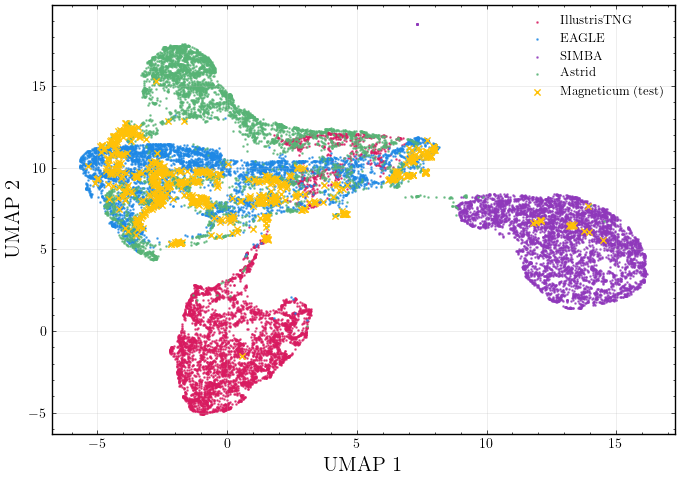

Visualization saved. Total samples: 20720


In [8]:
plt.figure(figsize=(7, 5))
colors = ['#D81B60','#1E88E5','#8F38BB','#57B375','#FFC107']
# colors = ['#E74C3C', '#3498DB', '#27AE60', '#9B59B6', '#F39C12']
for i, model_name in enumerate(simulation_models):
    mask = [label == model_name for label in all_labels_resnet]
    plt.scatter(embedding_umap_indv[mask, 0], embedding_umap_indv[mask, 1], marker='x' if model_name=='Magneticum' else '.',
               c=colors[i], label='Magneticum (test)' if model_name=='Magneticum' else model_name, alpha=1 if model_name=='Magneticum' else 0.7, s=20 if model_name=='Magneticum' else 3)
# plt.title('5-Channel ResNet Bottleneck by Simulation Model (PCA+t-SNE)')
plt.xlabel('UMAP 1',fontsize=15)
plt.ylabel('UMAP 2',fontsize=15)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
# Make the frame thicker
for spine in plt.gca().spines.values():
    spine.set_linewidth(1)
plt.tight_layout()
plt.savefig("umap_resnet_newnew.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Visualization saved. Total samples: {len(embedding_umap_indv)}")

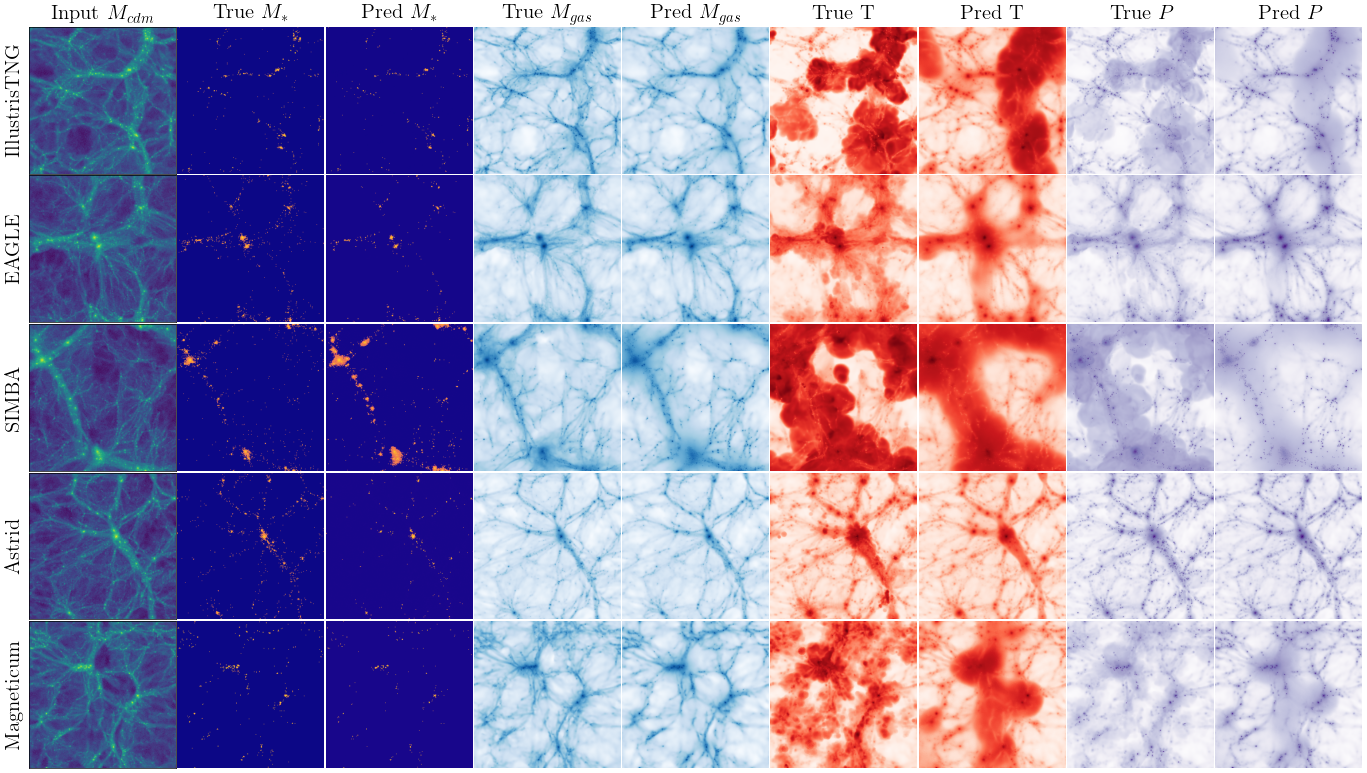

In [13]:
# Create figure with 2x9 grid of tightly tiled imshows
fig, axes = plt.subplots(5, 9, figsize=(17.2, 9.65))
fig.subplots_adjust(wspace=0.00, hspace=0.00)

channels = results['channels']
tot_mass_all = results['tot_mass_all']
params_list_all = results['params_list_all']

for row in range(5):
    sample_idx = row * 5
    
    # Column 0: Input DM map
    axes[row, 0].imshow(tot_mass_all[sample_idx], cmap='viridis')
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])
    if row == 0:
        axes[row, 0].set_title('Input $M_{cdm}$', fontsize=15)
    
    # Add dataset label on left
    # param_text = f"$\\Omega_m$={params_list_all[sample_idx][0]:.2f}, $\\sigma_8$={params_list_all[sample_idx][1]:.2f}"
    axes[row, 0].set_ylabel(f"{simulation_models[row]}", fontsize=15)
    
    # Columns 1-8: Channel pairs (true, pred)
    for ch_idx, (true_all, pred_all, pred_col, cmap, label) in enumerate(channels):
        col_true = 1 + ch_idx * 2
        col_pred = col_true + 1
        
        # True channel
        axes[row, col_true].imshow(true_all[sample_idx], cmap=cmap)
        # axes[row, col_true].set_xticks([])
        # axes[row, col_true].set_yticks([])
        axes[row, col_true].axis('off')
        if row == 0:
            axes[row, col_true].set_title(f'True {label}', fontsize=15)
        
        # Predicted channel
        axes[row, col_pred].imshow(pred_all[sample_idx][pred_col], cmap=cmap)
        # axes[row, col_pred].set_xticks([])
        # axes[row, col_pred].set_yticks([])
        axes[row, col_pred].axis('off')
        if row == 0:
            axes[row, col_pred].set_title(f'Pred {label}', fontsize=15)

# plt.tight_layout()
plt.subplots_adjust(wspace=0.01)
plt.savefig('grid_newnew.png')
plt.show()

/tmp/ipykernel_3988131/367198733.py:48: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 32)


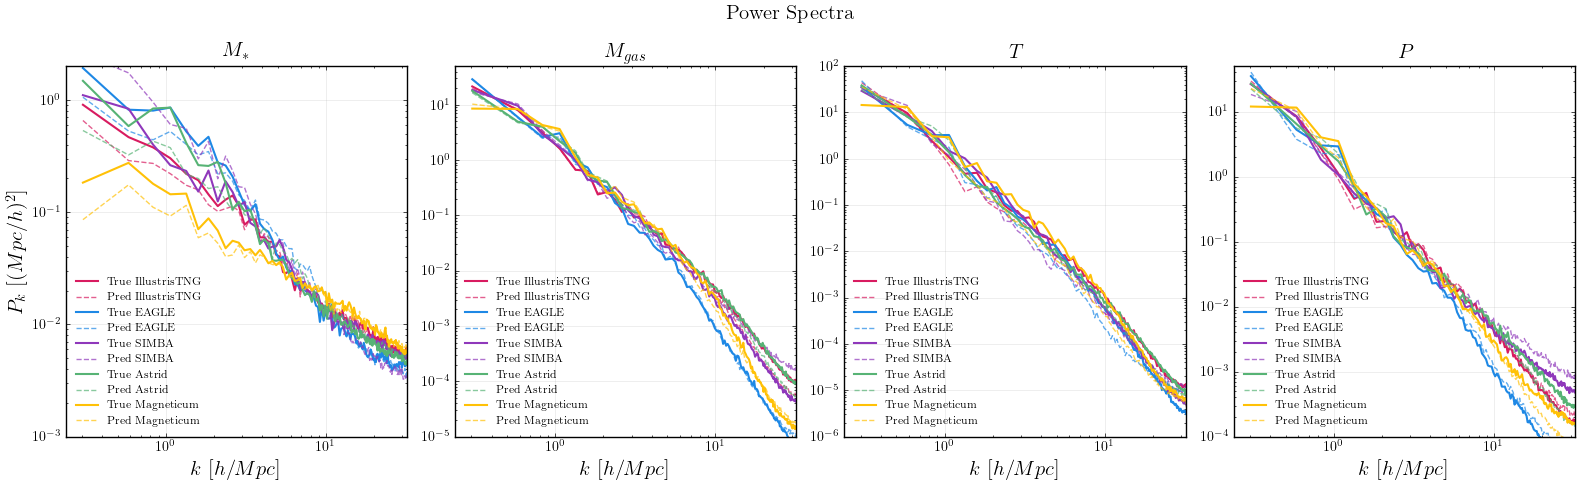

In [12]:
# ====================================================
# POWER SPECTRA FOR ALL THREE SIMULATIONS (OVERLAID)
# ====================================================

# Create figure with 1x4 subplots for power spectra
fig, axes = plt.subplots(1, 4, figsize=(16,5))

# Extract power spectra data from output dictionary
pk_results_all_channels = [
    results['power_spectra']['star'], 
    results['power_spectra']['gas'], 
    results['power_spectra']['T'], 
    results['power_spectra']['P']
]
pk_labels = ['$M_*$', '$M_{gas}$', '$T$', '$P$']
pk_colors = ['plasma', 'Blues', 'Reds', 'Purples']
sim_colors = ['#D81B60','#1E88E5','#8F38BB','#57B375','#FFC107']  # Different colors for each simulation
ranges = [(1e-3,2),(1e-5,50),(1e-6,100),(1e-4,50)]

# Plot for each channel
for ch_idx, (pk_res, label, cmap, r) in enumerate(zip(pk_results_all_channels, pk_labels, pk_colors, ranges)):
    ax = axes[ch_idx]
    
    # Plot each simulation
    for sim_idx in range(5):  # 3 simulations
        sample_idx = sim_idx * 5  # Each simulation has 5 samples
        sim_color = sim_colors[sim_idx]
        sim_name = simulation_models[sim_idx]
        
        k = pk_res[sample_idx]['k']
        pk_true = pk_res[sample_idx]['pk_true']
        valid = k > 0
        
        # True power spectrum for this simulation
        line_true, = ax.loglog(k[valid], pk_true[valid], '-', color=sim_color, lw=1.5, 
                              label=f'True {sim_name}')
        
        # Prediction (just one example from the 5 noise realisations)
        pk_pred = pk_res[sample_idx]['pk_pred']  # Use first noise realisation as example
        line_pred, = ax.loglog(k[valid], pk_pred[valid], '--', color=sim_color, alpha=0.7, lw=1, 
                              label=f'Pred {sim_name}')
    
    # Formatting
    ax.set_title(label, fontsize=15)
    ax.set_xlabel('$k$ [$h/Mpc$]', fontsize=15)
    if ch_idx==0:
        ax.set_ylabel('$P_k$ [$(Mpc/h)^2$]', fontsize=15)
    ax.set_xlim(0, 32)
    ax.set_ylim(r[0],r[1])
    ax.grid(alpha=0.3)
    ax.legend(loc='lower left', fontsize=8)
    
    for spine in ax.spines.values():
        spine.set_linewidth(1)

# Overall title and layout
fig.suptitle("Power Spectra", fontsize=15, weight='bold')
plt.tight_layout()
# plt.savefig('grid2.pdf')
plt.show()

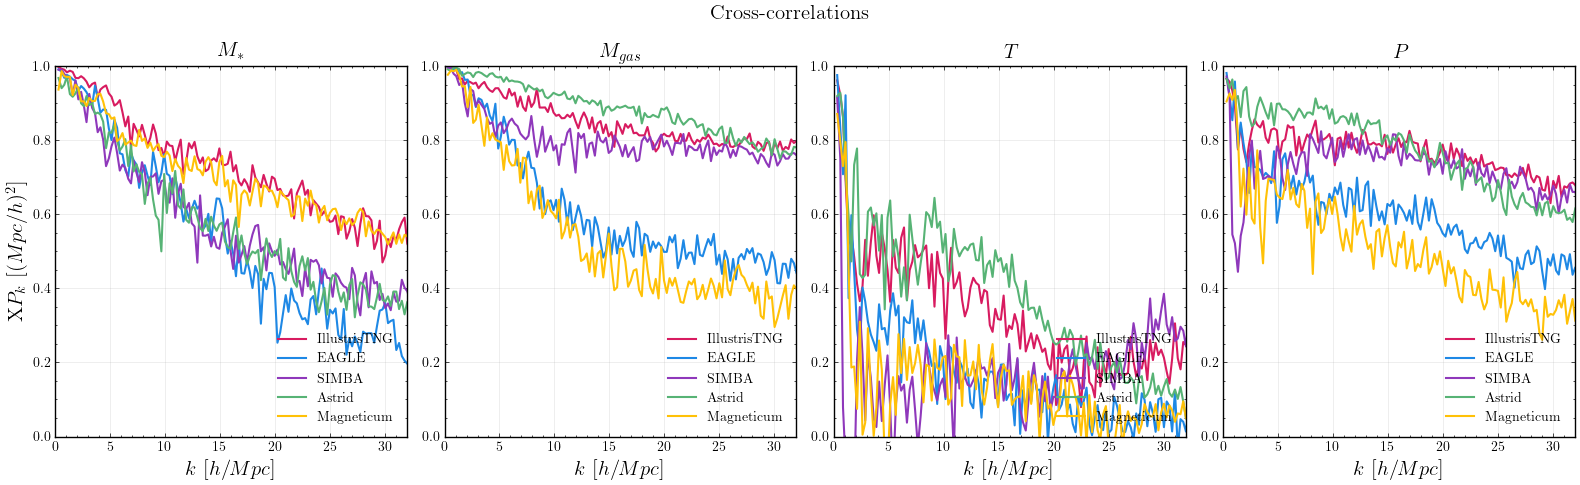

In [13]:
# ====================================================
# CROSS-CORRELATIONS FOR ALL THREE SIMULATIONS
# ====================================================

# Create figure with 1x4 subplots for correlations
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

# Extract correlation data from output dictionary
corr_results = [
    results['correlations']['star'], 
    results['correlations']['gas'], 
    results['correlations']['T'], 
    results['correlations']['P']
]
pk_labels = ['$M_*$', '$M_{gas}$', '$T$', '$P$']
pk_colors = ['plasma', 'Blues', 'Reds', 'Purples']
simulation_names = ['IllustrisTNG', 'Magneticum', 'SIMBA']
sim_colors = ['#D81B60','#1E88E5','#8F38BB','#57B375','#FFC107']  # Different colors for each simulation
# Plot for each channel
for ch_idx, (corr_res, label, cmap) in enumerate(zip(corr_results, pk_labels, pk_colors)):
    ax = axes[ch_idx]
    
    # Plot each simulation
    for sim_idx in range(5):  # 3 simulations
        sample_idx = sim_idx * 5  # Each simulation has 5 samples
        sim_color = sim_colors[sim_idx]
        sim_name = simulation_models[sim_idx]
        
        # Use first sample from each simulation as example
        r = corr_res[sample_idx]['r']
        xi = corr_res[sample_idx]['xi']
        
        line, = ax.plot(r, xi, '-', color=sim_color, lw=1.5, label=sim_name)
    
    # Formatting
    ax.set_title(label, fontsize=15)
    ax.set_xlabel('$k$ [$h/Mpc$]', fontsize=15)
    if ch_idx==0:
        ax.set_ylabel('$\\mathrm{X}P_k$ [$(Mpc/h)^2$]', fontsize=15)
    ax.set_xlim(0, 32)
    if ch_idx==2:
        ax.set_ylim(0, 1)
    else:
        ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.legend(loc='lower right', fontsize=10)
    
    for spine in ax.spines.values():
        spine.set_linewidth(1)

# Overall title and layout
fig.suptitle("Cross-correlations ", fontsize=15, fontweight='bold')
plt.tight_layout()
# plt.savefig('grid3.pdf')
plt.show()

In [9]:
from scipy.spatial import cKDTree

all_labels_resnet = pipeline.get_labels()

def closest_pair(A,B):
    # Build tree from B
    tree = cKDTree(B)
    # Query nearest neighbor in B for each point in A
    distances, indices_B = tree.query(A, k=1)
    i_A = np.argmin(distances)  # index in A (relative to A)
    i_B = indices_B[i_A]        # index in B (relative to B)
    return i_A, i_B

# Find closest pair between two datasets
A = X_resnet_indv[5000*1:5000*2]  # EAGLE data
B = X_resnet_indv[5000*3:5000*4]  # Astrid data

idx_A, idx_B = closest_pair(A,B)

abs_idx_A, abs_idx_B = idx_A+5000*1, idx_B+5000*3

start = X_resnet_indv[abs_idx_A]  # EAGLE data
end = X_resnet_indv[abs_idx_B]

def interpolate(x,y,n=5):
    d = 1/n
    interpolants = []
    for i in range(n+1):
        interpolants.append(x*d*i + (1-d*i)*y)
    return interpolants

interpolants = interpolate(start,end)

idx_inter = []
for pt in interpolants:
    _,b=closest_pair([pt],X_resnet_indv)
    idx_inter.append(b)

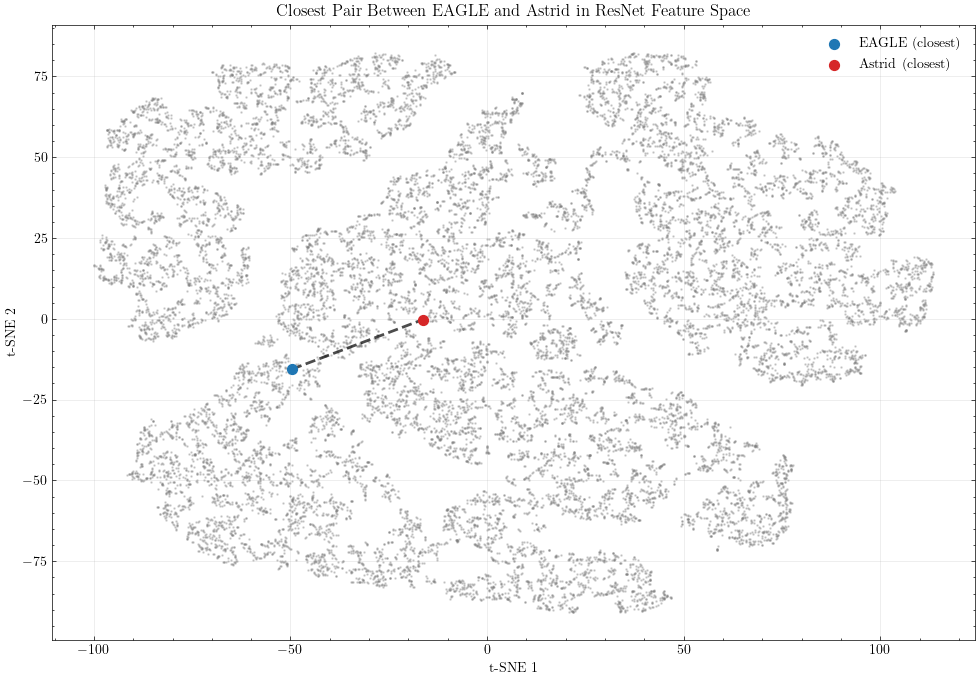


For simulation plotting:
EAGLE index: 5963
Astrid index: 15574


In [23]:
# Plot the results
plt.figure(figsize=(10, 7))

# Get all labels and t-SNE coordinates
labels = np.asarray(all_labels_resnet)

# Plot each model
highlight_pt = {
    'EAGLE':  (5000,'tab:blue'),
    'Astrid': (16703,'tab:red')
}

for model_name in simulation_models:
    mask = (labels == model_name)
    X_model = embedding_tsne_indv[mask, 0]  # x coordinates
    Y_model = embedding_tsne_indv[mask, 1]  # y coordinates

    plt.scatter(X_model, Y_model, marker='.', c='gray', alpha=0.3, s=3)

    if model_name == 'EAGLE' or model_name == 'Astrid':
        X_highlight = embedding_tsne_indv[highlight_pt[model_name][0], 0]
        Y_highlight = embedding_tsne_indv[highlight_pt[model_name][0], 1]
        plt.scatter(X_highlight, Y_highlight, marker='o', c=highlight_pt[model_name][1], s=50, 
                    linewidth=1, label=f'{model_name} (closest)', zorder=5)
    
X_line = [embedding_tsne_indv[highlight_pt['EAGLE'][0], 0], embedding_tsne_indv[highlight_pt['Astrid'][0], 0]]
Y_line = [embedding_tsne_indv[highlight_pt['EAGLE'][0], 1], embedding_tsne_indv[highlight_pt['Astrid'][0], 1]]
plt.plot(X_line, Y_line, 'k--', alpha=0.7, linewidth=2)

plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('Closest Pair Between EAGLE and Astrid in ResNet Feature Space')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# For the dual simulation plotting, use these indices:
print(f"\nFor simulation plotting:")
print(f"EAGLE index: {abs_idx_A}")
print(f"Astrid index: {abs_idx_B}")

Dataset shape: (20000, 8)
Number of classes: 4
Class names: ['Astrid' 'EAGLE' 'IllustrisTNG' 'SIMBA']
Train set: 12000 samples
Validation set: 4000 samples
Test set: 4000 samples
Training MLP classifier...
Training Accuracy: 0.9669
Validation Accuracy: 0.9620
Test Accuracy: 0.9615

Overfitting Analysis:
Train-Validation Gap: 0.0049
Train-Test Gap: 0.0054
✅ Good: Small train-validation gap, low overfitting risk


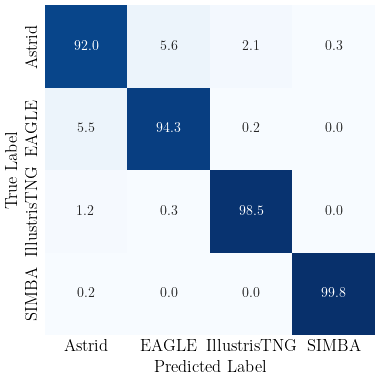

In [30]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import warnings
import scienceplots
plt.style.use('science')
warnings.filterwarnings('ignore')

# ====================================================
# MLP CLASSIFIER FOR RESNET FEATURES
# ====================================================

# Prepare the data
X = np.asarray(X_resnet_indv[:5000*4]) 
y = np.asarray(all_labels_resnet[:5000*4]) 

# Encode string labels to integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_  # Get the original string class names

print(f"Dataset shape: {X.shape}")
print(f"Number of classes: {len(class_names)}")
print(f"Class names: {class_names}")

# Split the data into train/validation/test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp  # 0.25 * 0.8 = 0.2 of total
)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples") 
print(f"Test set: {X_test.shape[0]} samples")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Train MLP classifier with validation monitoring
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),  # 3 hidden layers
    activation='relu',
    solver='adam',
    alpha=0.001,  # L2 regularization
    batch_size='auto',
    learning_rate='adaptive',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,  # Use 10% of training data for internal validation
    n_iter_no_change=15,  # Stop if no improvement for 15 iterations
    tol=1e-4  # Tolerance for optimization
)

print("Training MLP classifier...")
mlp.fit(X_train_scaled, y_train)

# Make predictions on all sets
y_train_pred = mlp.predict(X_train_scaled)
y_val_pred = mlp.predict(X_val_scaled)
y_test_pred = mlp.predict(X_test_scaled)

# Calculate accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Calculate overfitting metrics
train_val_gap = train_accuracy - val_accuracy
train_test_gap = train_accuracy - test_accuracy

print(f"\nOverfitting Analysis:")
print(f"Train-Validation Gap: {train_val_gap:.4f}")
print(f"Train-Test Gap: {train_test_gap:.4f}")

if train_val_gap > 0.1:
    print("⚠️  WARNING: Large train-validation gap suggests overfitting!")
elif train_val_gap > 0.05:
    print("⚠️  CAUTION: Moderate train-validation gap, monitor closely")
else:
    print("✅ Good: Small train-validation gap, low overfitting risk")

# Generate confusion matrix (using test set)
cm = confusion_matrix(y_test, y_test_pred)
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# ====================================================
# SIMPLIFIED 5x5 CONFUSION MATRIX
# ====================================================

plt.figure(figsize=(4, 4))

# Create simplified heatmap
sns.heatmap(
    cm_percentage, 
    annot=True, 
    fmt='.1f', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names,
    cbar=False
)

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)

# Keep only labels, no tick marks
plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=True)
plt.tick_params(axis='y', which='both', left=False, right=False, labelleft=True)

plt.xticks(rotation=0, fontsize=12)   # Horizontal x labels
plt.yticks(rotation=90, fontsize=12)  # Vertical y labels

plt.tight_layout()
plt.savefig('cm.png')
plt.show()


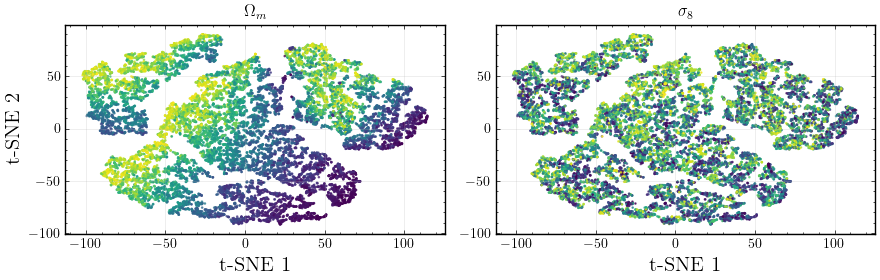

Visualization saved. Total samples: 20720


In [26]:
all_cosmo_params, all_astro_params = pipeline.get_parameters()

# Visualize
plt.figure(figsize=(9, 3))
colors = ['#D81B60','#1E88E5','#8F38BB','#57B375','#FFC107']
# colors = ['#E74C3C', '#3498DB', '#27AE60', '#9B59B6', '#F39C12']
for j in range(2):
    plt.subplot(1,2,j+1)
    params = np.vstack(all_cosmo_params)
    plt.scatter(embedding_tsne_indv[:, 0], embedding_tsne_indv[:, 1], marker= '.',
               c=params[:,j], alpha= 0.7, s= 3)
    # plt.title('5-Channel ResNet Bottleneck by Simulation Model (PCA+t-SNE)')
    plt.xlabel('t-SNE 1',fontsize=15)
    if not j:
        plt.ylabel('t-SNE 2',fontsize=15)
    plt.title('$\\sigma_8$' if j else '$\\Omega_m$')
    plt.grid(True, alpha=0.3)
    # Make the frame thicker
    for spine in plt.gca().spines.values():
        spine.set_linewidth(1)
plt.tight_layout()
plt.savefig('cosmo.png')
plt.show()
print(f"Visualization saved. Total samples: {len(embedding_tsne_indv)}")

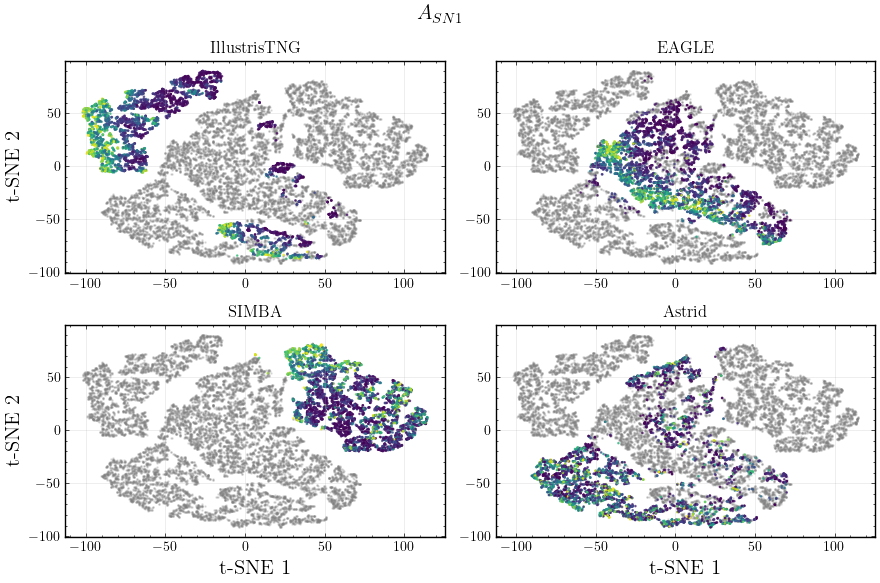

Visualization saved. Total samples: 20720


In [27]:
# Visualize
plt.figure(figsize=(9, 6))
colors = ['#D81B60','#1E88E5','#8F38BB','#57B375','#FFC107']
# colors = ['#E74C3C', '#3498DB', '#27AE60', '#9B59B6', '#F39C12']
for i, (model_name,params) in enumerate(zip(simulation_models[:4],all_astro_params[:4])):
    plt.subplot(2,2,i+1)
    params = np.asarray(params)
    mask = np.asarray([label == model_name for label in all_labels_resnet])
    
    plt.scatter(embedding_tsne_indv[~mask, 0], embedding_tsne_indv[~mask, 1], marker= '.',
               c='gray', alpha= 0.2, s= 3)
    plt.scatter(embedding_tsne_indv[mask, 0], embedding_tsne_indv[mask, 1], marker= '.',
               c=params[:,0], alpha= 0.7, s= 3)
    # plt.title('5-Channel ResNet Bottleneck by Simulation Model (PCA+t-SNE)')
    if i>1:
        plt.xlabel('t-SNE 1',fontsize=15)
    if not i%2:
        plt.ylabel('t-SNE 2',fontsize=15)
    plt.title(model_name)
    plt.grid(True, alpha=0.3)
    # Make the frame thicker
    for spine in plt.gca().spines.values():
        spine.set_linewidth(1)
plt.suptitle('$A_{SN1}$',fontsize=15)
plt.tight_layout()
plt.savefig('asn1.png')
plt.show()
print(f"Visualization saved. Total samples: {len(embedding_tsne_indv)}")

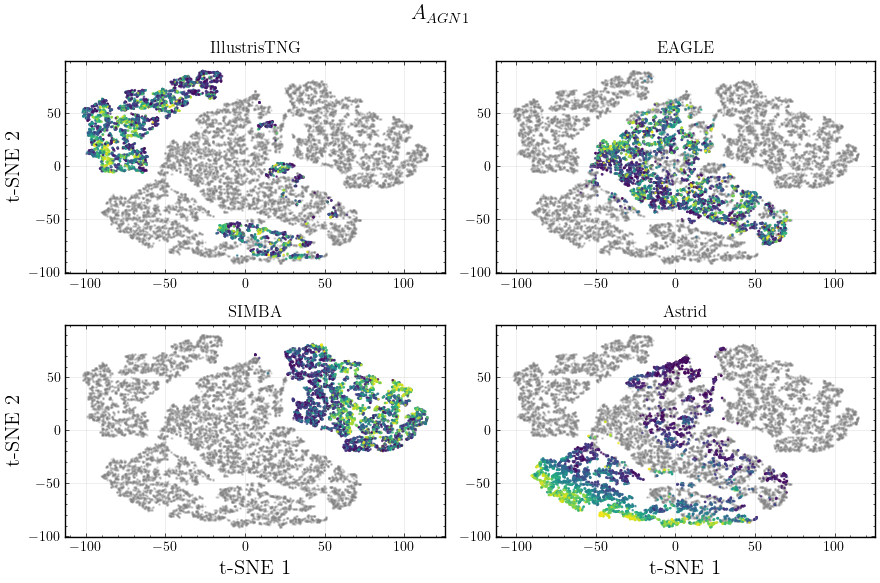

Visualization saved. Total samples: 20720


In [29]:
# Visualize
plt.figure(figsize=(9, 6))
colors = ['#D81B60','#1E88E5','#8F38BB','#57B375','#FFC107']
# colors = ['#E74C3C', '#3498DB', '#27AE60', '#9B59B6', '#F39C12']
for i, (model_name,params) in enumerate(zip(simulation_models[:4],all_astro_params[:4])):
    plt.subplot(2,2,i+1)
    params = np.asarray(params)
    mask = np.asarray([label == model_name for label in all_labels_resnet])
    
    plt.scatter(embedding_tsne_indv[~mask, 0], embedding_tsne_indv[~mask, 1], marker= '.',
               c='gray', alpha= 0.2, s= 3)
    plt.scatter(embedding_tsne_indv[mask, 0], embedding_tsne_indv[mask, 1], marker= '.',
               c=params[:,2], alpha= 0.7, s= 3)
    # plt.title('5-Channel ResNet Bottleneck by Simulation Model (PCA+t-SNE)')
    if i>1:
        plt.xlabel('t-SNE 1',fontsize=15)
    if not i%2:
        plt.ylabel('t-SNE 2',fontsize=15)
    plt.title(model_name)
    plt.grid(True, alpha=0.3)
    # Make the frame thicker
    for spine in plt.gca().spines.values():
        spine.set_linewidth(1)
plt.suptitle('$A_{AGN1}$',fontsize=15)
plt.tight_layout()
plt.savefig('agn1.png')
plt.show()
print(f"Visualization saved. Total samples: {len(embedding_tsne_indv)}")